# 2주차. Attention 이전의 자연어

In [1]:
%pip install -q torch numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## 데이터

In [2]:
# 실제 번역 데이터를 내려받는다. Tatoeba 문장을 모아둔 영-한 쌍 6,394개 (CC-BY 2.0, manythings.org/anki)
import re
import urllib.request
import zipfile
import io

url = "https://www.manythings.org/anki/kor-eng.zip"
req = urllib.request.Request(url, headers={
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36",
    "Accept": "*/*",
})
raw = urllib.request.urlopen(req, timeout=30).read()

with zipfile.ZipFile(io.BytesIO(raw)) as zf:
    text = zf.read("kor.txt").decode("utf-8")

lines = text.strip().split("\n")
pairs = [(line.split("\t")[0], line.split("\t")[1]) for line in lines]
print(f"전체 문장 쌍: {len(pairs)}개")
print(pairs[0])


전체 문장 쌍: 6394개
('Go.', '가.')


In [3]:
# 영어는 단어 단위, 한국어는 음절 단위로 쪼개고 너무 길거나 짧은 문장은 뺀다
def tok_en(s):
    return re.findall(r"[a-z']+|[.!?]", s.lower())


filtered = []
for en, ko in pairs:
    en_toks = tok_en(en)
    ko_chars = list(ko)  # 공백도 하나의 토큰으로 남긴다
    if 2 <= len(en_toks) <= 8 and 2 <= len(ko_chars) <= 12:
        filtered.append((en, ko, en_toks, ko_chars))

print(f"필터 후: {len(filtered)}개")
for en, ko, _, _ in filtered[:5]:
    print(f"{en:20s} -> {ko}")


필터 후: 2405개
Go.                  -> 가.
Hi.                  -> 안녕.
Run!                 -> 뛰어!
Run!                 -> 도망가!
Run.                 -> 뛰어.


In [4]:
# 어휘를 만들고, 이후 모든 섹션이 공유해서 쓸 train/val/test로 나눈다
import collections
import random
import torch

random.seed(0)
torch.manual_seed(0)
random.shuffle(filtered)

PAD, SOS, EOS, UNK = 0, 1, 2, 3


def build_vocab(seqs):
    counter = collections.Counter(t for s in seqs for t in s)
    itos = ["<pad>", "<sos>", "<eos>", "<unk>"] + [w for w, _ in counter.most_common()]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos, counter


en_stoi, en_itos, en_counter = build_vocab([e for _, _, e, _ in filtered])
ko_stoi, ko_itos, _ = build_vocab([k for _, _, _, k in filtered])
print(f"영어 어휘: {len(en_itos)}개, 한국어 어휘: {len(ko_itos)}개")


def encode(seq, stoi, add_eos):
    ids = [stoi.get(t, UNK) for t in seq]
    if add_eos:
        ids = ids + [EOS]
    return torch.tensor(ids, dtype=torch.long)


pair_data = [(encode(e, en_stoi, False), encode(k, ko_stoi, True)) for _, _, e, k in filtered]

n_val, n_test = 300, 300
val_pairs = pair_data[:n_val]
test_pairs = pair_data[n_val:n_val + n_test]
train_pairs = pair_data[n_val + n_test:]
train_sents = filtered[n_val + n_test:]  # RNN/LSTM 절에서 실제 단어 빈도를 셀 때 test와 안 겹치게

print(f"train {len(train_pairs)}개 | val {len(val_pairs)}개 | test {len(test_pairs)}개")


영어 어휘: 1564개, 한국어 어휘: 764개
train 1805개 | val 300개 | test 300개


## 1. RNN (Recurrent Neural Network)

In [5]:
# 같은 W_x, W_h를 모든 시점에서 재사용하며 h_t를 갱신한다
import numpy as np

np.random.seed(0)
d_in, d_hidden = 4, 3

W_x = np.random.randn(d_hidden, d_in) * 0.1
W_h = np.random.randn(d_hidden, d_hidden) * 0.1

def rnn_step(x_t, h_prev):
    return np.tanh(W_x @ x_t + W_h @ h_prev)

seq = np.random.randn(5, d_in)  # 5토큰짜리 문장
h = np.zeros(d_hidden)
for t, x_t in enumerate(seq):
    h = rnn_step(x_t, h)
    print(f"t={t}  h_t = {h.round(3)}")

t=0  h_t = [ 0.527 -0.067  0.335]
t=1  h_t = [ 0.124 -0.306  0.172]
t=2  h_t = [ 0.116  0.258 -0.145]
t=3  h_t = [-0.067 -0.286  0.203]
t=4  h_t = [-0.067  0.198 -0.211]


In [6]:
# 문장이 길어져도 파라미터 수는 그대로다
import torch
import torch.nn as nn

rnn = nn.RNN(input_size=4, hidden_size=3, batch_first=True)
n_params = sum(p.numel() for p in rnn.parameters())

for seq_len in [5, 20, 100]:
    x = torch.randn(1, seq_len, 4)
    out, h_n = rnn(x)
    print(f"문장 길이 {seq_len:>3} | 출력 토큰 수 {out.shape[1]:>3} | hidden 크기 {h_n.shape[-1]} | 파라미터 수 {n_params}")


문장 길이   5 | 출력 토큰 수   5 | hidden 크기 3 | 파라미터 수 27
문장 길이  20 | 출력 토큰 수  20 | hidden 크기 3 | 파라미터 수 27
문장 길이 100 | 출력 토큰 수 100 | hidden 크기 3 | 파라미터 수 27


### 기울기 소실

상위 20개 단어: ['.', '?', 'you', 'tom', 'is', 'i', 'a', 'the', 'to', 'do', '!', 'it', 'this', "i'm", 'are', 'my', "don't", 'me', 'have', 'that']


RNN epoch    0 | train loss 3.030 acc 0.05 | val loss 3.017 acc 0.07


RNN epoch  150 | train loss 2.989 acc 0.08 | val loss 2.997 acc 0.07


RNN epoch  300 | train loss 3.012 acc 0.03 | val loss 2.989 acc 0.06


RNN epoch  450 | train loss 2.999 acc 0.05 | val loss 3.001 acc 0.06


...

RNN epoch  900 | train loss 3.015 acc 0.04 | val loss 3.002 acc 0.04


RNN epoch 1050 | train loss 3.006 acc 0.07 | val loss 3.000 acc 0.04


RNN epoch 1200 | train loss 3.013 acc 0.05 | val loss 3.000 acc 0.06


RNN epoch 1350 | train loss 3.014 acc 0.06 | val loss 3.008 acc 0.06


RNN epoch 1499 | train loss 3.008 acc 0.04 | val loss 3.010 acc 0.03


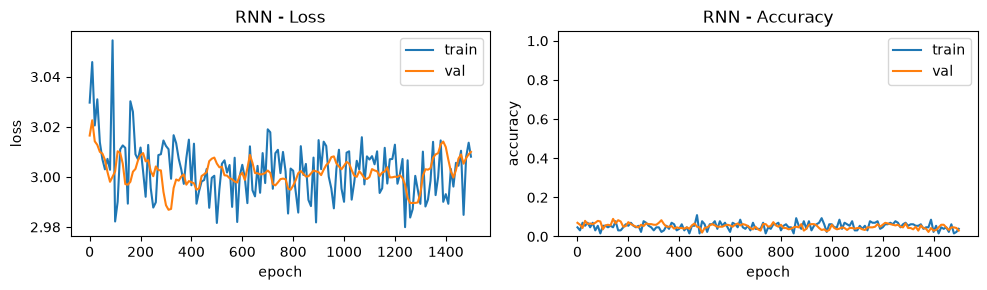

RNN TEST 정확도 0.06  (우연 0.05, 1.2배)
i'm my don't tom to you ...         | 정답(번역) 난    | 예측 내
! ? it is me have ...               | 정답(번역) !    | 예측 안해
that are do . my is ...             | 정답(번역) 저    | 예측 는
to is this ? don't it ...           | 정답(번역) 로    | 예측 안해
. it you . it have ...              | 정답(번역) .    | 예측 그
this have it i don't ? ...          | 정답(번역) 이    | 예측 는
me tom is me the me ...             | 정답(번역) 나를   | 예측 해
it don't to that that the ...       | 정답(번역) 그것   | 예측 로


[(0, 3.0296642780303955, 0.046875, 3.016507863998413, 0.07000000029802322),
 (10, 3.0458567142486572, 0.03125, 3.0226166248321533, 0.05999999865889549),
 (20, 3.0205323696136475, 0.0703125, 3.014209032058716, 0.04333333298563957),
 (30, 3.030987024307251, 0.0546875, 3.0127851963043213, 0.07999999821186066),
 (40, 3.013810634613037, 0.0703125, 3.009986639022827, 0.06333333253860474),
 (50, 3.007066488265991, 0.046875, 3.0093069076538086, 0.06666667014360428),
 (60, 3.0030105113983154, 0.0703125, 3.006838083267212, 0.06333333253860474),
 (70, 3.007209062576294, 0.03125, 3.0019359588623047, 0.07000000029802322),
 (80, 3.002835512161255, 0.0546875, 2.9980380535125732, 0.07999999821186066),
 (90, 3.0545318126678467, 0.015625, 3.0001585483551025, 0.07666666805744171),
 (100, 2.9821937084198, 0.0546875, 3.0021796226501465, 0.036666665226221085),
 (110, 2.9900882244110107, 0.0546875, 3.01023268699646, 0.05666666850447655),
 (120, 3.010990858078003, 0.046875, 3.0095736980438232, 0.0599999986588

In [7]:
# 코퍼스에서 가장 흔한 단어 20개로, 문장 맨 앞 단어의 "한국어 번역"을 끝까지 기억해야 맞히는 과제를 만든다
import torch.nn as nn
import matplotlib.pyplot as plt

top_words = [w for w, _ in collections.Counter(t for _, _, e, _ in train_sents for t in e).most_common(20)]
word2id = {w: i for i, w in enumerate(top_words)}
print("상위 20개 단어:", top_words)

# 단어 대 단어 대응표 (직역 수준의 고정된 번역)
gloss = {
    ".": ".", "?": "?", "!": "!", "i": "나", "tom": "톰", "you": "너", "is": "는", "a": "한",
    "the": "그", "to": "로", "this": "이", "i'm": "난", "do": "해", "are": "임",
    "have": "있어", "it": "그것", "that": "저", "my": "내", "in": "에", "me": "나를",
    "don't": "안해", "can": "할수있어", "want": "원해", "know": "알아",
    "will": "할거야", "was": "였어", "he": "그가", "she": "그녀가", "like": "좋아해",
}
ko_words = [gloss[w] for w in top_words]
ko2id = {w: i for i, w in enumerate(ko_words)}
gloss_id_of = torch.tensor([ko2id[gloss[w]] for w in top_words])  # 영어 id -> 한국어 번역 id

seq_len = 30
hidden_size = 32


class Recall(nn.Module):
    def __init__(self, cell, forget_bias=False):
        super().__init__()
        self.emb = nn.Embedding(len(top_words), hidden_size)
        self.rnn = cell(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, len(ko_words))
        if forget_bias:
            for name, p in self.rnn.named_parameters():
                if "bias" in name:
                    n = p.shape[0] // 4
                    p.data[n:2 * n].fill_(1.0)  # forget gate가 잘 안 잊도록 초기화

    def forward(self, x):
        _, state = self.rnn(self.emb(x))
        h = state[0] if isinstance(state, tuple) else state
        return self.fc(h[-1])


def make_recall_batch(bs):
    idx = torch.randint(0, len(top_words), (bs, seq_len))
    y = gloss_id_of[idx[:, 0]]  # 정답은 맨 첫 단어의 한국어 번역
    return idx, y


recall_val_x, recall_val_y = make_recall_batch(300)
recall_test_x, recall_test_y = make_recall_batch(300)
chance_acc = 1 / len(ko_words)


def plot_curves(history, title):
    epochs, train_loss, train_acc, val_loss, val_acc = zip(*history)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(epochs, train_loss, label="train")
    axes[0].plot(epochs, val_loss, label="val")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()
    axes[1].plot(epochs, train_acc, label="train")
    axes[1].plot(epochs, val_acc, label="val")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def train_recall(model, name, epochs=1500, log_every=150, record_every=10):
    opt = torch.optim.Adam(model.parameters(), lr=5e-3)
    criterion = nn.CrossEntropyLoss()
    history = []
    for epoch in range(epochs):
        x, y = make_recall_batch(128)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

        if epoch % record_every == 0 or epoch == epochs - 1:
            train_acc = (logits.argmax(-1) == y).float().mean().item()
            with torch.no_grad():
                val_logits = model(recall_val_x)
                val_loss = criterion(val_logits, recall_val_y).item()
                val_acc = (val_logits.argmax(-1) == recall_val_y).float().mean().item()
            history.append((epoch, loss.item(), train_acc, val_loss, val_acc))
            if epoch % log_every == 0 or epoch == epochs - 1:
                print(f"{name} epoch {epoch:>4} | train loss {loss.item():.3f} acc {train_acc:.2f} "
                      f"| val loss {val_loss:.3f} acc {val_acc:.2f}")
    plot_curves(history, name)

    with torch.no_grad():
        test_logits = model(recall_test_x)
        test_acc = (test_logits.argmax(-1) == recall_test_y).float().mean().item()
    print(f"{name} TEST 정확도 {test_acc:.2f}  (우연 {chance_acc:.2f}, {test_acc / chance_acc:.1f}배)")

    id2word = {i: w for w, i in word2id.items()}
    id2ko = {i: w for w, i in ko2id.items()}
    pred = test_logits.argmax(-1)
    for i in range(8):
        seq_preview = " ".join(id2word[t.item()] for t in recall_test_x[i][:6]) + " ..."
        print(f"{seq_preview:35s} | 정답(번역) {id2ko[recall_test_y[i].item()]:4s} | 예측 {id2ko[pred[i].item()]}")
    return history


torch.manual_seed(0)
rnn_model = Recall(nn.RNN)
train_recall(rnn_model, "RNN")


## 2. LSTM (Long Short-Term Memory)

In [8]:
# 게이트가 늘어난 만큼 LSTM과 GRU는 RNN보다 파라미터가 많다
import torch.nn as nn

cmp_hidden = 64
cmp_input = 32

rnn = nn.RNN(cmp_input, cmp_hidden, batch_first=True)
lstm = nn.LSTM(cmp_input, cmp_hidden, batch_first=True)
gru = nn.GRU(cmp_input, cmp_hidden, batch_first=True)


def count_params(m):
    return sum(p.numel() for p in m.parameters())


for name, m in [("RNN", rnn), ("LSTM", lstm), ("GRU", gru)]:
    print(f"{name:4s} 파라미터 수: {count_params(m):,}")

RNN  파라미터 수: 6,272
LSTM 파라미터 수: 25,088
GRU  파라미터 수: 18,816


In [9]:
# LSTM은 hidden state 외에 cell state도 함께 내보낸다
x = torch.randn(1, 6, cmp_input)
out, (h_n, c_n) = lstm(x)

print("LSTM 출력: h_n, c_n 두 개")
print("h_n 크기:", h_n.shape[-1])
print("c_n 크기:", c_n.shape[-1])


LSTM 출력: h_n, c_n 두 개
h_n 크기: 64
c_n 크기: 64


LSTM epoch    0 | train loss 3.027 acc 0.05 | val loss 3.002 acc 0.05


LSTM epoch  150 | train loss 2.542 acc 0.13 | val loss 2.456 acc 0.18


LSTM epoch  300 | train loss 1.787 acc 0.32 | val loss 1.851 acc 0.29


LSTM epoch  450 | train loss 1.276 acc 0.55 | val loss 1.315 acc 0.55


LSTM epoch  600 | train loss 0.987 acc 0.64 | val loss 0.985 acc 0.64


...

LSTM epoch  900 | train loss 1.014 acc 0.65 | val loss 0.872 acc 0.67


LSTM epoch 1050 | train loss 1.335 acc 0.55 | val loss 1.356 acc 0.64


LSTM epoch 1200 | train loss 0.785 acc 0.67 | val loss 0.789 acc 0.69


LSTM epoch 1350 | train loss 0.738 acc 0.70 | val loss 0.687 acc 0.69


LSTM epoch 1499 | train loss 0.697 acc 0.70 | val loss 0.671 acc 0.69


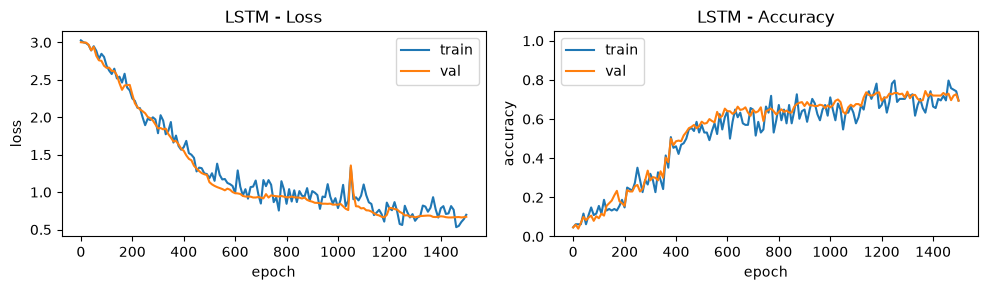

LSTM TEST 정확도 0.73  (우연 0.05, 14.5배)
i'm my don't tom to you ...         | 정답(번역) 난    | 예측 난
! ? it is me have ...               | 정답(번역) !    | 예측 는
that are do . my is ...             | 정답(번역) 저    | 예측 저
to is this ? don't it ...           | 정답(번역) 로    | 예측 로
. it you . it have ...              | 정답(번역) .    | 예측 저
this have it i don't ? ...          | 정답(번역) 이    | 예측 이
me tom is me the me ...             | 정답(번역) 나를   | 예측 나를
it don't to that that the ...       | 정답(번역) 그것   | 예측 저


[(0, 3.027435302734375, 0.046875, 3.0023155212402344, 0.046666666865348816),
 (10, 3.002049446105957, 0.0625, 2.9982166290283203, 0.05999999865889549),
 (20, 2.9910545349121094, 0.0625, 2.997371196746826, 0.03999999910593033),
 (30, 2.9645442962646484, 0.0625, 2.969266176223755, 0.07000000029802322),
 (40, 2.8926663398742676, 0.1171875, 2.894545793533325, 0.10000000149011612),
 (50, 2.9486050605773926, 0.0625, 2.9396579265594482, 0.0833333358168602),
 (60, 2.8875322341918945, 0.109375, 2.8201324939727783, 0.09666666388511658),
 (70, 2.7784016132354736, 0.1484375, 2.7608213424682617, 0.1066666692495346),
 (80, 2.8475136756896973, 0.109375, 2.753519058227539, 0.07999999821186066),
 (90, 2.8061230182647705, 0.1171875, 2.687875509262085, 0.10333333164453506),
 (100, 2.6879801750183105, 0.15625, 2.659888982772827, 0.09333333373069763),
 (110, 2.6232364177703857, 0.1171875, 2.6619679927825928, 0.11666666716337204),
 (120, 2.57755184173584, 0.1875, 2.618359088897705, 0.1066666692495346),
 (13

In [10]:
# 같은 과제, 같은 설정에서 RNN을 LSTM으로만 바꿔서 다시 학습시킨다
torch.manual_seed(0)
lstm_model = Recall(nn.LSTM, forget_bias=True)
train_recall(lstm_model, "LSTM")


### GRU

In [11]:
# GRU는 cell state가 없어 LSTM보다 파라미터가 적다
lstm_params = count_params(lstm)
gru_params = count_params(gru)
print(f"LSTM 파라미터 수: {lstm_params:,}")
print(f"GRU  파라미터 수: {gru_params:,}")
print(f"GRU / LSTM 비율: {gru_params / lstm_params:.2f}")

LSTM 파라미터 수: 25,088
GRU  파라미터 수: 18,816
GRU / LSTM 비율: 0.75


### 입출력 길이 문제

In [12]:
# RNN은 입력을 몇 토큰 읽든 출력도 똑같은 개수만큼 나온다
x = torch.randn(1, 7, cmp_input)  # 7토큰짜리 입력
out, _ = rnn(x)
print(f"입력 토큰 수: {x.shape[1]}")
print(f"출력 개수:   {out.shape[1]}")

입력 토큰 수: 7
출력 개수:   7


## 3. Seq2Seq (Sequence-to-Sequence)

epoch  0 | train loss 5.765 acc 0.16 | val loss 4.516 acc 0.15


epoch 10 | train loss 2.976 acc 0.43 | val loss 3.181 acc 0.42


epoch 20 | train loss 2.286 acc 0.54 | val loss 2.845 acc 0.47


epoch 30 | train loss 1.703 acc 0.64 | val loss 2.734 acc 0.49


epoch 40 | train loss 1.222 acc 0.75 | val loss 2.762 acc 0.49


epoch 50 | train loss 0.843 acc 0.84 | val loss 2.850 acc 0.49


epoch 59 | train loss 0.592 acc 0.90 | val loss 2.963 acc 0.49


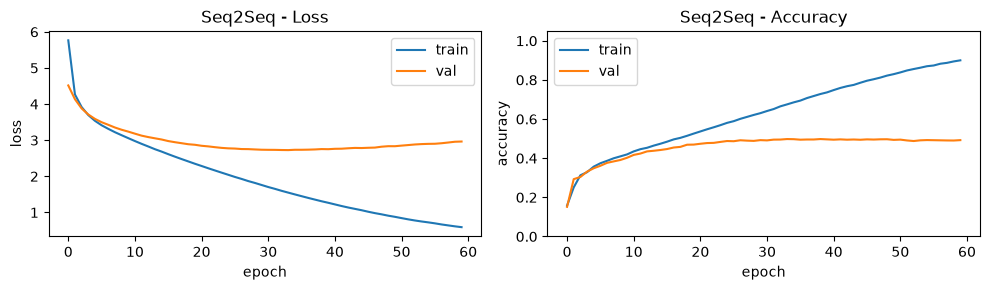

Seq2Seq TEST 정확도 0.49  (우연 0.0013, 373.0배)


In [13]:
# 인코더-디코더를 학습시키며 실제 번역 데이터로 loss와 정확도가 어떻게 움직이는지 본다
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

embed_dim, s2s_hidden = 64, 128
en_emb = nn.Embedding(len(en_itos), embed_dim, padding_idx=PAD)
ko_emb = nn.Embedding(len(ko_itos), embed_dim, padding_idx=PAD)
encoder = nn.LSTM(embed_dim, s2s_hidden, batch_first=True)
decoder = nn.LSTM(embed_dim, s2s_hidden, batch_first=True)
output_layer = nn.Linear(s2s_hidden, len(ko_itos))

params = list(en_emb.parameters()) + list(ko_emb.parameters()) \
    + list(encoder.parameters()) + list(decoder.parameters()) + list(output_layer.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)


def make_batch(items):
    src_list = [s for s, _ in items]
    tgt_list = [t for _, t in items]
    src_lens = torch.tensor([len(s) for s in src_list])
    order = src_lens.argsort(descending=True)
    src_list = [src_list[i] for i in order]
    tgt_list = [tgt_list[i] for i in order]
    src_lens = src_lens[order]
    src = pad_sequence(src_list, batch_first=True, padding_value=PAD)
    tgt_full = pad_sequence(tgt_list, batch_first=True, padding_value=PAD)
    sos_col = torch.full((len(tgt_list), 1), SOS, dtype=torch.long)
    tgt_in = torch.cat([sos_col, tgt_full[:, :-1]], dim=1)
    return src, src_lens, tgt_in, tgt_full


def run_epoch(dataset, train, bs=64):
    if train:
        random.shuffle(dataset)
    total_loss, total_tok, correct = 0, 0, 0
    for i in range(0, len(dataset), bs):
        batch = dataset[i:i + bs]
        src, src_lens, tgt_in, tgt_out = make_batch(batch)
        if train:
            optimizer.zero_grad()
        packed = pack_padded_sequence(en_emb(src), src_lens, batch_first=True)
        _, (h, c) = encoder(packed)
        dec_out, _ = decoder(ko_emb(tgt_in), (h, c))
        logits = output_layer(dec_out)
        loss = criterion(logits.reshape(-1, len(ko_itos)), tgt_out.reshape(-1))
        if train:
            loss.backward()
            optimizer.step()
        mask = tgt_out != PAD
        correct += ((logits.argmax(-1) == tgt_out) & mask).sum().item()
        total_tok += mask.sum().item()
        total_loss += loss.item() * mask.sum().item()
    return total_loss / total_tok, correct / total_tok


history = []
for epoch in range(60):
    train_loss, train_acc = run_epoch(train_pairs, train=True)
    val_loss, val_acc = run_epoch(val_pairs, train=False)
    history.append((epoch, train_loss, train_acc, val_loss, val_acc))
    if epoch % 10 == 0 or epoch == 59:
        print(f"epoch {epoch:>2} | train loss {train_loss:.3f} acc {train_acc:.2f} "
              f"| val loss {val_loss:.3f} acc {val_acc:.2f}")

epochs_, tl, ta, vl, va = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(epochs_, tl, label="train")
axes[0].plot(epochs_, vl, label="val")
axes[0].set_title("Seq2Seq - Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[1].plot(epochs_, ta, label="train")
axes[1].plot(epochs_, va, label="val")
axes[1].set_title("Seq2Seq - Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
plt.tight_layout()
plt.show()

test_loss, test_acc = run_epoch(test_pairs, train=False)
s2s_chance = 1 / len(ko_itos)
print(f"Seq2Seq TEST 정확도 {test_acc:.2f}  (우연 {s2s_chance:.4f}, {test_acc / s2s_chance:.1f}배)")


In [14]:
# 학습된 모델로 실제 번역을 몇 개 뽑아본다 (테스트셋, 학습 때 보지 못한 문장)
test_sents = filtered[n_val:n_val + n_test]


@torch.no_grad()
def translate(en_toks, max_len=15):
    src = encode(en_toks, en_stoi, add_eos=False).unsqueeze(0)
    _, (h, c) = encoder(en_emb(src))
    ys = [SOS]
    for _ in range(max_len):
        y_in = torch.tensor([[ys[-1]]])
        dec_out, (h, c) = decoder(ko_emb(y_in), (h, c))
        nxt = output_layer(dec_out[:, -1]).argmax(-1).item()
        if nxt == EOS:
            break
        ys.append(nxt)
    return " ".join(ko_itos[i] for i in ys[1:])


for en, ko, en_toks, _ in test_sents[:8]:
    pred = translate(en_toks)
    print(f"{en:22s} | 정답 {ko:14s} | 예측 {pred}")


Tom broke up with Mary. | 정답 톰은 메리와 헤어졌다.   | 예측 톰 은   이 것   소 심 한 다 .
Tom is a single dad.   | 정답 톰은 싱글 대디야.     | 예측 톰 은   꽤   의 욕 적 이 야 .
Monkeys climb trees.   | 정답 원숭이는 나무를 탄다.   | 예측 물 에   가 져 .
You should go to bed.  | 정답 너는 자야해         | 예측 기 분 이   가 고   있 어 .
How annoying!          | 정답 이렇게 짜증날 수가!    | 예측 이 렇 게   흥 미 롭 다 니 !
I got engaged.         | 정답 나 약혼했어.        | 예측 나 는   영 화 를   싫 다 .
Read this.             | 정답 이걸 읽어.         | 예측 이 것 을   들 어 봐 .
Anybody home?          | 정답 누구 집에 있어?      | 예측 집 에   누 군 가   있 어 ?


### 고정 길이 병목

In [15]:
# 입력 문장이 길어질수록 context 하나로는 부족해 번역 정확도가 떨어진다 (test셋 기준)
bucket_correct = collections.defaultdict(int)
bucket_total = collections.defaultdict(int)

for src, tgt in test_pairs:
    src_len = len(src)
    with torch.no_grad():
        packed = pack_padded_sequence(en_emb(src.unsqueeze(0)), torch.tensor([src_len]), batch_first=True)
        _, (h, c) = encoder(packed)
        tgt_in = torch.cat([torch.tensor([[SOS]]), tgt[:-1].unsqueeze(0)], dim=1)
        dec_out, _ = decoder(ko_emb(tgt_in), (h, c))
        pred = output_layer(dec_out).argmax(-1).squeeze(0)
    bucket = "짧음(2~4단어)" if src_len <= 4 else ("중간(5~6단어)" if src_len <= 6 else "긺(7~8단어)")
    bucket_correct[bucket] += (pred == tgt).sum().item()
    bucket_total[bucket] += len(tgt)

for bucket in ["짧음(2~4단어)", "중간(5~6단어)", "긺(7~8단어)"]:
    acc = bucket_correct[bucket] / bucket_total[bucket]
    print(f"입력 길이 {bucket} | 정확도 {acc:.2f}")


입력 길이 짧음(2~4단어) | 정확도 0.52
입력 길이 중간(5~6단어) | 정확도 0.47
입력 길이 긺(7~8단어) | 정확도 0.44
